# **Customer Segmentation & Churn Pattern Analytics in European Banking**

## **Problem Statement**

Despite having rich customer-level data, banks face challanges in :

* Identifying high-risk customer segments
* Understanding churn differences by geography and demographics
* Quantifying the financial profile of churned customers

## **Project Objectives**

* Measure overall churn rate
* Identify churn distribution across customer segments
* Compare churn behavior across European regions

## **Secondary Objectives**

* Understanding churn among high-value customers
* Evaluate engagement and tenure patterns
* Support strategic planning and marketing decisions

### **Data Ingestion and Validation**

In [1]:
### Load libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load dataset

In [2]:
df = pd.read_csv('C:/Users/acer/Unified Mentors Project/01_European_bank/Data/European_Bank.csv')

In [3]:
df.head()         # General structure inspection

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()    # preliminary information of the columns to deal with

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.shape    # determining the shape of the dataset

(10000, 14)

#### Validate engagement and product fields

In [6]:
print("Missing values for each column")
print(df.isnull().sum())  # checking missing values

Missing values for each column
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
duplicate_count = df.duplicated().sum()
print(f"Duplicates values for each column: {duplicate_count}") # Checking for duplicate values

Duplicates values for each column: 0


In [8]:
print(df.describe())  # Sanity Check

          Year    CustomerId   CreditScore           Age        Tenure  \
count  10000.0  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    2025.0  1.569094e+07    650.528800     38.921800      5.012800   
std        0.0  7.193619e+04     96.653299     10.487806      2.892174   
min     2025.0  1.556570e+07    350.000000     18.000000      0.000000   
25%     2025.0  1.562853e+07    584.000000     32.000000      3.000000   
50%     2025.0  1.569074e+07    652.000000     37.000000      5.000000   
75%     2025.0  1.575323e+07    718.000000     44.000000      7.000000   
max     2025.0  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499797   
min         0.000000       1.000000      0.00000        0.000

In [9]:
print(df['NumOfProducts'].value_counts())  # Value range

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


#### Ensure binary variables consistency

In [10]:
print(df['IsActiveMember'].unique()) # ensuring consistency
print(df['HasCrCard'].unique())
print(df['Exited'].unique())

[1 0]
[1 0]
[1 0]


#### Confirm churn labelling accuracy

In [11]:
print(df['Exited'].value_counts())         # Value count in the column 

Exited
0    7963
1    2037
Name: count, dtype: int64


## Data Cleaning and preparation

In [12]:
# Remove non-analytical fields (surname)

df = df.drop(['Surname'], axis = 1)            # Removing surname 

In [13]:
# Converting Categorical Variables

df['Gender'] = df['Gender'].astype('category')
df['Geography'] = df['Geography'].astype('category')

In [14]:
# Creating derived segmentation fields

# Age Segment
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,30,45,60,100], labels=['<30','30-45','46-60','60+'])

# Credit Score Band
df['CreditScoreBand'] = pd.cut(df['CreditScore'], bins=[300,600,750,850], labels=['Low','Medium','High'])

# Tenure Groups
df['TenureGroup'] = pd.cut(df['Tenure'], bins=[0,3,7,10], labels=['New','Mid-term','Long-term'])

# Balance Segments
df['BalanceSegment'] = pd.cut(df['Balance'], bins=[-1,0,50000,250000], labels=['Zero','Low','High'])

In [15]:
# previewing new segmentation fields
print("\nPreview of Segmentation fields:")
print(df[['Age', 'AgeGroup','CreditScore','CreditScoreBand', 'Tenure', 'TenureGroup', 'Balance', 'BalanceSegment']].head())


Preview of Segmentation fields:
   Age AgeGroup  CreditScore CreditScoreBand  Tenure TenureGroup    Balance  \
0   42    30-45          619          Medium       2         New       0.00   
1   41    30-45          608          Medium       1         New   83807.86   
2   42    30-45          502             Low       8   Long-term  159660.80   
3   39    30-45          699          Medium       1         New       0.00   
4   43    30-45          850            High       2         New  125510.82   

  BalanceSegment  
0           Zero  
1           High  
2           High  
3           Zero  
4           High  


### Churn Distribution Analysis

In [16]:
# Overall Churn Rate

overall_churn = df['Exited'].mean()
print(f"Overall Churn Rate : {overall_churn:.2%}")

Overall Churn Rate : 20.37%


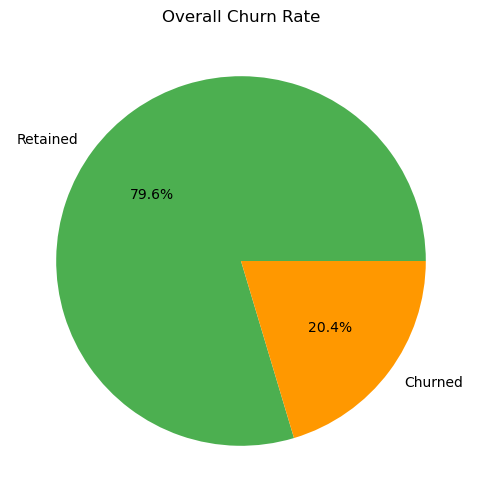

In [17]:
# Pie chart for overall churn rate
plt.figure(figsize=(8,6))
labels = ["Retained","Churned"]
sizes = [df['Exited'].value_counts()[0], df['Exited'].value_counts()[1]]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=["#4CAF50","#FF9800"])
plt.title("Overall Churn Rate")
plt.savefig("C:/Users/acer/Unified Mentors Project/01_European_bank/Images/Overall_churn_rate.png")

#### Segment wise Churn Rates

In [18]:
# Age

print("\nChurn Rate by Age Group:")
print((df.groupby("AgeGroup")["Exited"].mean() * 100).round(2))


Churn Rate by Age Group:
AgeGroup
<30       7.52
30-45    15.74
46-60    51.12
60+      24.78
Name: Exited, dtype: float64


C:\Users\acer\AppData\Local\Temp\ipykernel_21364\2881451205.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print((df.groupby("AgeGroup")["Exited"].mean() * 100).round(2))


In [19]:
# Geography

print("\nChurn Rate by Geography:")
print((df.groupby("Geography")["Exited"].mean() * 100).round(2))


Churn Rate by Geography:
Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64


C:\Users\acer\AppData\Local\Temp\ipykernel_21364\726138155.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print((df.groupby("Geography")["Exited"].mean() * 100).round(2))


In [20]:
# Tenure Group

print("\nChurn Rate by Tenure Group:")
print((df.groupby("TenureGroup")["Exited"].mean() * 100).round(2))


Churn Rate by Tenure Group:
TenureGroup
New          20.89
Mid-term     19.64
Long-term    20.45
Name: Exited, dtype: float64


C:\Users\acer\AppData\Local\Temp\ipykernel_21364\1548828612.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print((df.groupby("TenureGroup")["Exited"].mean() * 100).round(2))


In [21]:
# Balance Segment

print("\nChurn Rate by Balance Segment:")
print((df.groupby("BalanceSegment")["Exited"].mean() * 100).round(2))


Churn Rate by Balance Segment:
BalanceSegment
Zero    13.82
Low     34.67
High    23.94
Name: Exited, dtype: float64


C:\Users\acer\AppData\Local\Temp\ipykernel_21364\406840558.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print((df.groupby("BalanceSegment")["Exited"].mean() * 100).round(2))


#### Churn contribution by segment size

In [22]:
# Total churned customers
total_churn = df["Exited"].sum()
print("\nTotal Churned Customers : ", total_churn)

# Contribution by Age Segment
churn_contribution_age = df.groupby("AgeGroup")["Exited"].sum() / total_churn * 100
print("\nChurn contribution by Age Segment : ", churn_contribution_age)

# Contribution by Credit Band
churn_contribution_credit = df.groupby("CreditScoreBand")["Exited"].sum() / total_churn * 100
print("\nChurn contribution by Credit Band : ", churn_contribution_credit)

# Contribution by Tenure Group
churn_contribution_tenure = df.groupby("TenureGroup")["Exited"].sum() / total_churn * 100
print("\nChurn contribution by Tenure Group : ", churn_contribution_tenure)

# Balance Segment contribution
churn_contribution_balance = df.groupby("BalanceSegment")["Exited"].sum() / total_churn * 100
print("\nChurn contribution by Balance Segment : ", churn_contribution_balance)


Total Churned Customers :  2037

Churn contribution by Age Segment :  AgeGroup
<30       7.265587
30-45    45.753559
46-60    41.335297
60+       5.645557
Name: Exited, dtype: float64

Churn contribution by Credit Band :  CreditScoreBand
Low       32.646048
Medium    51.988218
High      15.365734
Name: Exited, dtype: float64

Churn contribution by Tenure Group :  TenureGroup
New          31.713304
Mid-term     38.537064
Long-term    25.085911
Name: Exited, dtype: float64

Churn contribution by Balance Segment :  BalanceSegment
Zero    24.545901
Low      1.276387
High    74.128621
Name: Exited, dtype: float64


C:\Users\acer\AppData\Local\Temp\ipykernel_21364\2811673357.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_contribution_age = df.groupby("AgeGroup")["Exited"].sum() / total_churn * 100
C:\Users\acer\AppData\Local\Temp\ipykernel_21364\2811673357.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_contribution_credit = df.groupby("CreditScoreBand")["Exited"].sum() / total_churn * 100
C:\Users\acer\AppData\Local\Temp\ipykernel_21364\2811673357.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retai

C:\Users\acer\AppData\Local\Temp\ipykernel_21364\2482193414.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_churn_age = df.groupby("AgeGroup")["Exited"].mean() * 100
C:\Users\acer\AppData\Local\Temp\ipykernel_21364\2482193414.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_churn_age.index, y=segment_churn_age.values, palette="Set2")


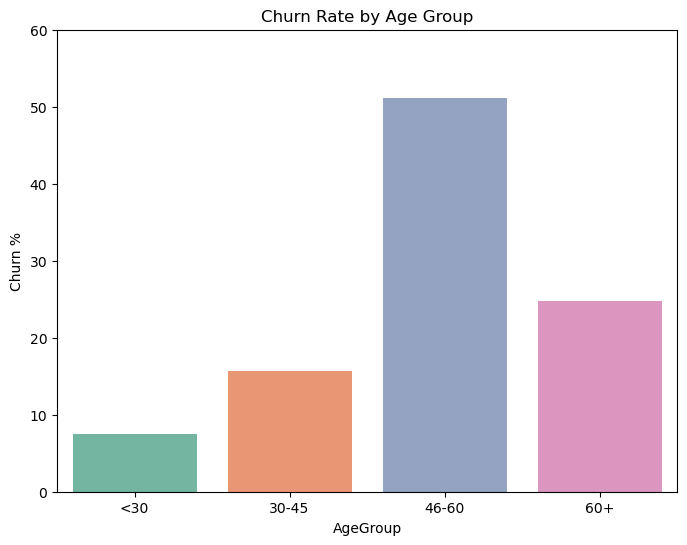

In [23]:
# Churn by segmentation fields

# Segment - Age
segment_churn_age = df.groupby("AgeGroup")["Exited"].mean() * 100
plt.figure(figsize=(8,6))
sns.barplot(x=segment_churn_age.index, y=segment_churn_age.values, palette="Set2")
plt.title("Churn Rate by Age Group")
plt.ylabel("Churn %")
plt.ylim(0, 60)
plt.savefig("C:/Users/acer/Unified Mentors Project/01_European_bank/Images/churn_by_age.png")

C:\Users\acer\AppData\Local\Temp\ipykernel_21364\2577500148.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_churn_balance = df.groupby("BalanceSegment")["Exited"].mean() * 100
C:\Users\acer\AppData\Local\Temp\ipykernel_21364\2577500148.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_churn_balance.index, y=segment_churn_balance.values, palette="Set2")


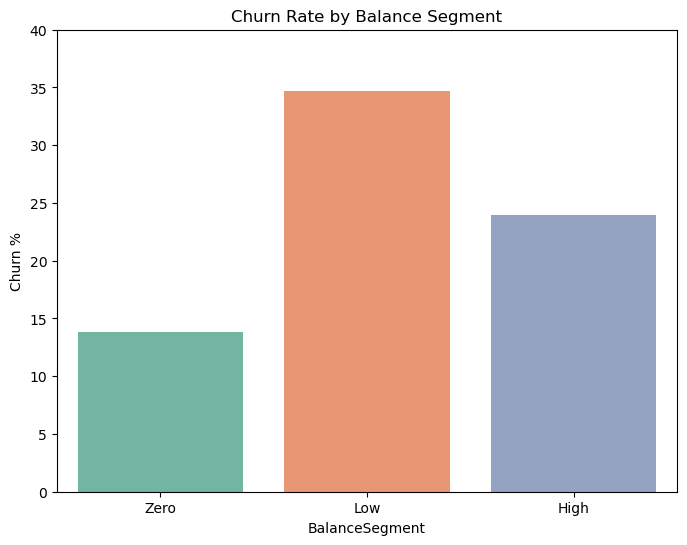

In [24]:
# segment - Balance

segment_churn_balance = df.groupby("BalanceSegment")["Exited"].mean() * 100

plt.figure(figsize=(8,6))
sns.barplot(x=segment_churn_balance.index, y=segment_churn_balance.values, palette="Set2")
plt.title("Churn Rate by Balance Segment")
plt.ylabel("Churn %")
plt.ylim(0, 40)
plt.savefig("C:/Users/acer/Unified Mentors Project/01_European_bank/Images/churn_by_balance.png")

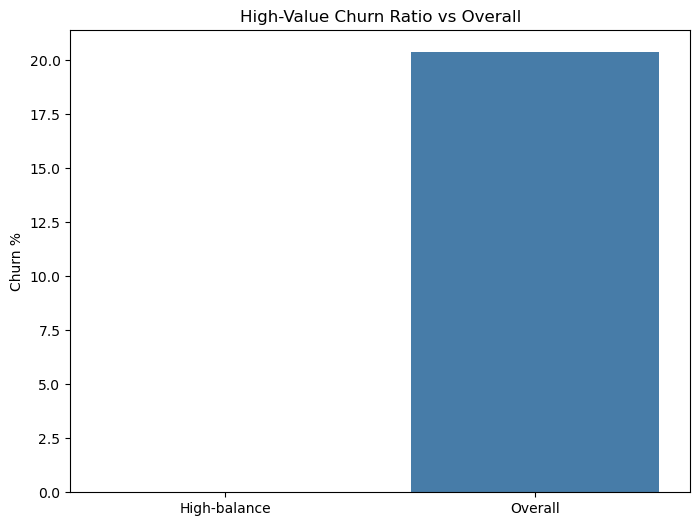

In [25]:
# High-Value Churn Ratio

high_value_churn = df[df['BalanceSegment']=="High-balance"]["Exited"].mean() * 100
overall_churn_rate = df['Exited'].mean() * 100

plt.figure(figsize=(8,6))
sns.barplot(x=["High-balance","Overall"], y=[high_value_churn, overall_churn_rate],hue=["High-balance", "Overall"], palette="Set1")
plt.title("High-Value Churn Ratio vs Overall")
plt.ylabel("Churn %")
plt.savefig("C:/Users/acer/Unified Mentors Project/01_European_bank/Images/high_value_churn_vs_Overall.png")

C:\Users\acer\AppData\Local\Temp\ipykernel_21364\1857676826.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  geo_churn = df.groupby("Geography")["Exited"].mean() * 100
C:\Users\acer\AppData\Local\Temp\ipykernel_21364\1857676826.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=geo_churn.index, y=geo_churn.values, palette="Set3")


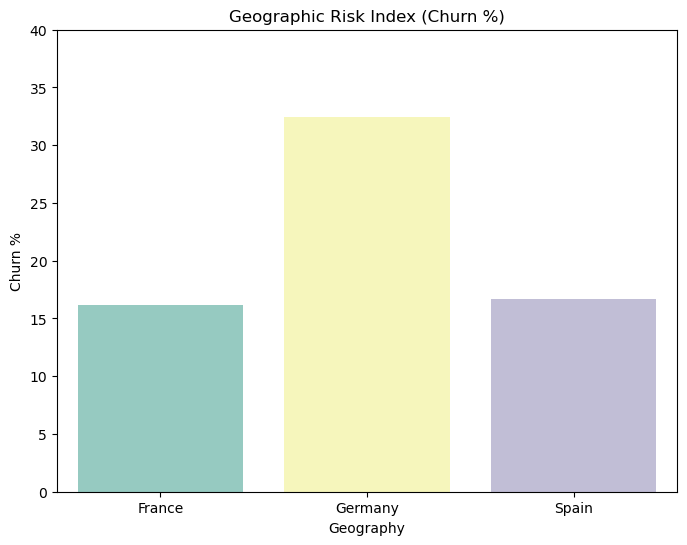

In [26]:
# Geography Risk Index

geo_churn = df.groupby("Geography")["Exited"].mean() * 100
plt.figure(figsize=(8,6))
sns.barplot(x=geo_churn.index, y=geo_churn.values, palette="Set3")
plt.title("Geographic Risk Index (Churn %)")
plt.ylabel("Churn %")
plt.ylim(0, 40)
plt.savefig("C:/Users/acer/Unified Mentors Project/01_European_bank/Images/geo_risk_index.png")

#### Comparison of churned vs retained profiles

In [27]:
# Create a mapping for churn status
status_labels = {0: "Retained", 1: "Churned"}

print("\nComparison of Churned vs Retained Profiles:")

# Group by Exited, calculate mean, round to 2 decimals, and relabel index
profile_comparison = (
    df.groupby("Exited")[['Age','CreditScore','Balance','EstimatedSalary','NumOfProducts']]
      .mean()
      .round(2)
      .rename(index=status_labels)   # relabel 0/1 to Retained/Churned
)
print(profile_comparison)


Comparison of Churned vs Retained Profiles:
            Age  CreditScore   Balance  EstimatedSalary  NumOfProducts
Exited                                                                
Retained  37.41       651.85  72745.30         99738.39           1.54
Churned   44.84       645.35  91108.54        101465.68           1.48


## Comparative Demographic Analysis

In [28]:
# Comparative Demographic Analysis

print("\n--- Gender-Based Churn Differences ---")
churn_by_gender = df.groupby("Gender")["Exited"].mean() * 100
gender_gap = churn_by_gender.max() - churn_by_gender.min()
print(churn_by_gender.round(2))
print(f"Gender Risk Gap: {gender_gap:.2f}%")

print("\n--- Geography-Age Interaction Analysis ---")
churn_by_geo_age = df.groupby(["Geography","AgeGroup"])["Exited"].mean() * 100
print(churn_by_geo_age.round(2))

print("\n--- Financial Stability vs Churn (Credit Score Band) ---")
print((df.groupby("CreditScoreBand")["Exited"].mean() * 100).round(2))

print("\n--- Financial Stability vs Churn (Balance Segment) ---")
print((df.groupby("BalanceSegment")["Exited"].mean() * 100).round(2))

print("\n--- Financial Stability vs Churn (Salary Quartile) ---")
df['SalaryQuartile'] = pd.qcut(df['EstimatedSalary'], 4, labels=['Q1','Q2','Q3','Q4'])
print((df.groupby("SalaryQuartile")["Exited"].mean() * 100).round(2))



--- Gender-Based Churn Differences ---
Gender
Female    25.07
Male      16.46
Name: Exited, dtype: float64
Gender Risk Gap: 8.62%

--- Geography-Age Interaction Analysis ---
Geography  AgeGroup
France     <30          4.91
           30-45       12.35
           46-60       45.79
           60+         19.91
Germany    <30         12.36
           30-45       26.09
           46-60       67.33
           60+         38.94
Spain      <30          8.60
           30-45       12.53
           46-60       40.66
           60+         20.83
Name: Exited, dtype: float64

--- Financial Stability vs Churn (Credit Score Band) ---
CreditScoreBand
Low       21.69
Medium    19.85
High      19.59
Name: Exited, dtype: float64

--- Financial Stability vs Churn (Balance Segment) ---
BalanceSegment
Zero    13.82
Low     34.67
High    23.94
Name: Exited, dtype: float64

--- Financial Stability vs Churn (Salary Quartile) ---
SalaryQuartile
Q1    20.00
Q2    19.80
Q3    20.12
Q4    21.56
Name: Exited, dt

C:\Users\acer\AppData\Local\Temp\ipykernel_21364\1595363204.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_gender = df.groupby("Gender")["Exited"].mean() * 100
C:\Users\acer\AppData\Local\Temp\ipykernel_21364\1595363204.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_geo_age = df.groupby(["Geography","AgeGroup"])["Exited"].mean() * 100
C:\Users\acer\AppData\Local\Temp\ipykernel_21364\1595363204.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True t

### High‑Value Customer Churn Analysis

In [29]:
# High-Value Customer Churn Analysis

print("\n--- High-Balance Churner Profile ---")
high_balance_churn = df[(df["BalanceSegment"]=="High-balance") & (df["Exited"]==1)]
print(high_balance_churn[["Balance","EstimatedSalary"]].describe())

print("\n--- Salary vs Balance Segment Patterns ---")
print(df.groupby("BalanceSegment")["EstimatedSalary"].mean().round(2))
print(df.groupby("BalanceSegment")["Exited"].mean().round(2))

print("\n--- Revenue Risk (Total Balance Lost to Churn) ---")
revenue_risk = df[df["Exited"]==1]["Balance"].sum()
print(f"Total balance lost due to churn: {revenue_risk:.2f}")


--- High-Balance Churner Profile ---
       Balance  EstimatedSalary
count      0.0              0.0
mean       NaN              NaN
std        NaN              NaN
min        NaN              NaN
25%        NaN              NaN
50%        NaN              NaN
75%        NaN              NaN
max        NaN              NaN

--- Salary vs Balance Segment Patterns ---
BalanceSegment
Zero     98983.56
Low     102212.66
High    100702.69
Name: EstimatedSalary, dtype: float64
BalanceSegment
Zero    0.14
Low     0.35
High    0.24
Name: Exited, dtype: float64

--- Revenue Risk (Total Balance Lost to Churn) ---
Total balance lost due to churn: 185588094.63


C:\Users\acer\AppData\Local\Temp\ipykernel_21364\3322755182.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("BalanceSegment")["EstimatedSalary"].mean().round(2))
C:\Users\acer\AppData\Local\Temp\ipykernel_21364\3322755182.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("BalanceSegment")["Exited"].mean().round(2))


C:\Users\acer\AppData\Local\Temp\ipykernel_21364\3185347858.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Inactive","Active"], y=[engagement_drop, active_churn], palette="Set1")


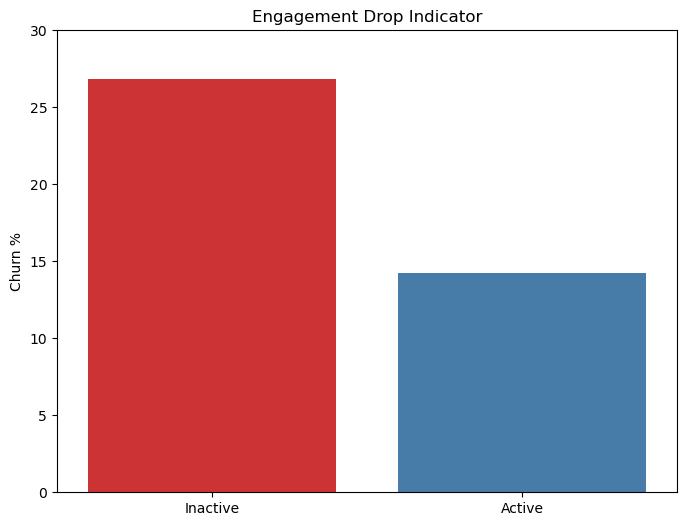

In [30]:
# Engagement Drop Indicator

engagement_drop = df[df['IsActiveMember']==0]["Exited"].mean() * 100
active_churn = df[df['IsActiveMember']==1]["Exited"].mean() * 100

plt.figure(figsize=(8,6))
sns.barplot(x=["Inactive","Active"], y=[engagement_drop, active_churn], palette="Set1")
plt.title("Engagement Drop Indicator")
plt.ylabel("Churn %")
plt.ylim(0, 30)
plt.savefig("C:/Users/acer/Unified Mentors Project/01_European_bank/Images/engagement_drop.png")
plt.show()